In [ ]:
%pip install puremacro


# Macroeconomía y Cambio Climático — El Modelo DICE y la Fijación de Precios al Carbono

**¿Cómo interactúan el crecimiento económico, las emisiones de gases de efecto invernadero y la retroalimentación climática a horizontes de un siglo?**

El modelo de Clima y Economía Integrados Dinámicamente (DICE), desarrollado por William Nordhaus (Premio Nobel 2018) y ampliado por Golosov, Hassler, Krusell y Tsyvinski (2014, *Econometrica*), es el marco canónico para evaluar:
1. **Acumulación de Carbono Atmosférico**: Dinámica del ciclo del carbono con 3 reservorios oceánicos/atmosféricos.
2. **Anomalías de Temperatura Superficial**: Forzamiento radiativo y absorción de calor oceánico.
3. **Daños Macroeconómicos del Clima**: Pérdidas no lineales de producción agregada $D(T_t) Y_t$.
4. **Fijación Óptima del Precio al Carbono**: Trayectorias del Costo Social del Carbono (CSC).

En este tutorial interactivo simulamos el modelo DICE a 150 años mediante `puremacro.climate.simulate_dice_model`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.climate import simulate_dice_model

## 1. Simulación del Modelo DICE: Escenario Base vs. Impuesto Acelerado al Carbono

In [2]:
res_base = simulate_dice_model(
    n_periods=30,
    time_step_years=5,
    start_year=2020,
    carbon_tax_initial=40.0,
    carbon_tax_growth=0.02,
)
print("=== Escenario Base ===")
print(res_base.summary())

res_policy = simulate_dice_model(
    n_periods=30,
    time_step_years=5,
    start_year=2020,
    carbon_tax_initial=80.0,
    carbon_tax_growth=0.035,
)
print("\n=== Escenario con Impuesto Acelerado ===")
print(res_policy.summary())

=== Escenario Base ===
DICE Climate-Macroeconomic Integration Model (Nordhaus / Golosov et al.)
Horizon                         : 30 periods (5-year steps)
Initial Social Cost of Carbon   : $40.25 / tCO2
Peak Global Surface Warming     : 1.71 °C above pre-industrial
End-Century (2100) Damage Share : 0.63% of Global GDP
------------------------------------------------------------------------
Key Benchmark Years:
  Year 2025: Temp +1.40°C | Emissions 29.1 GtCO2 | Damage 0.46% | SCC $44.6/t
  Year 2050: Temp +1.47°C | Emissions 19.5 GtCO2 | Damage 0.51% | SCC $73.2/t
  Year 2075: Temp +1.52°C | Emissions 15.1 GtCO2 | Damage 0.54% | SCC $120.2/t
  Year 2100: Temp +1.63°C | Emissions 8.6 GtCO2 | Damage 0.63% | SCC $197.5/t

=== Escenario con Impuesto Acelerado ===
DICE Climate-Macroeconomic Integration Model (Nordhaus / Golosov et al.)
Horizon                         : 30 periods (5-year steps)
Initial Social Cost of Carbon   : $80.50 / tCO2
Peak Global Surface Warming     : 1.46 °C above p

## 2. Anomalías de Calentamiento Superficial

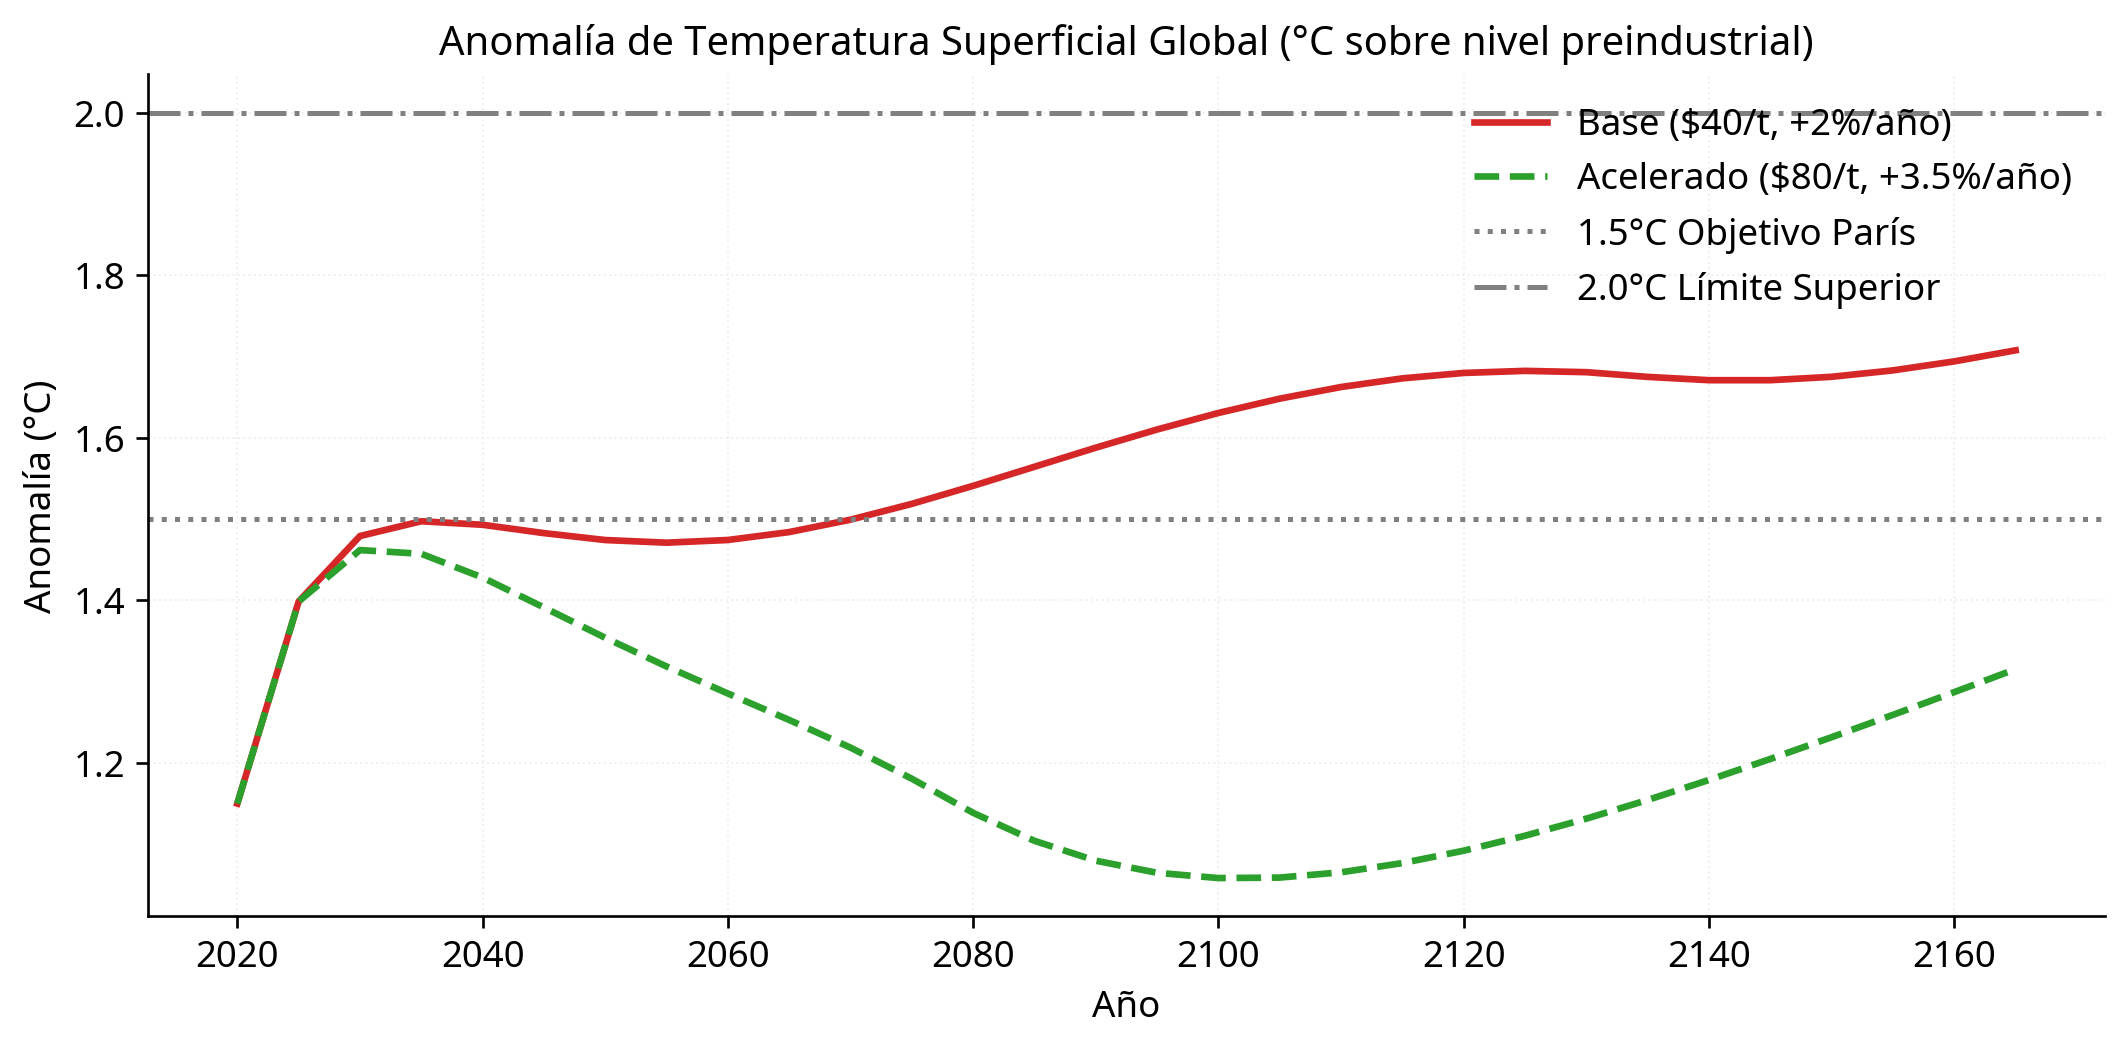

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(res_base.trajectories.index, res_base.trajectories["temperature_anomaly"], color="#d62728", lw=2, label="Base ($40/t, +2%/año)")
ax.plot(res_policy.trajectories.index, res_policy.trajectories["temperature_anomaly"], color="#2ca02c", lw=2, linestyle="--", label="Acelerado ($80/t, +3.5%/año)")
ax.axhline(1.5, color="gray", linestyle=":", label="1.5°C Objetivo París")
ax.axhline(2.0, color="gray", linestyle="-.", label="2.0°C Límite Superior")
ax.set_title("Anomalía de Temperatura Superficial Global (°C sobre nivel preindustrial)", fontsize=12, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Anomalía (°C)")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Emisiones Globales de CO2 (GtCO2/año)

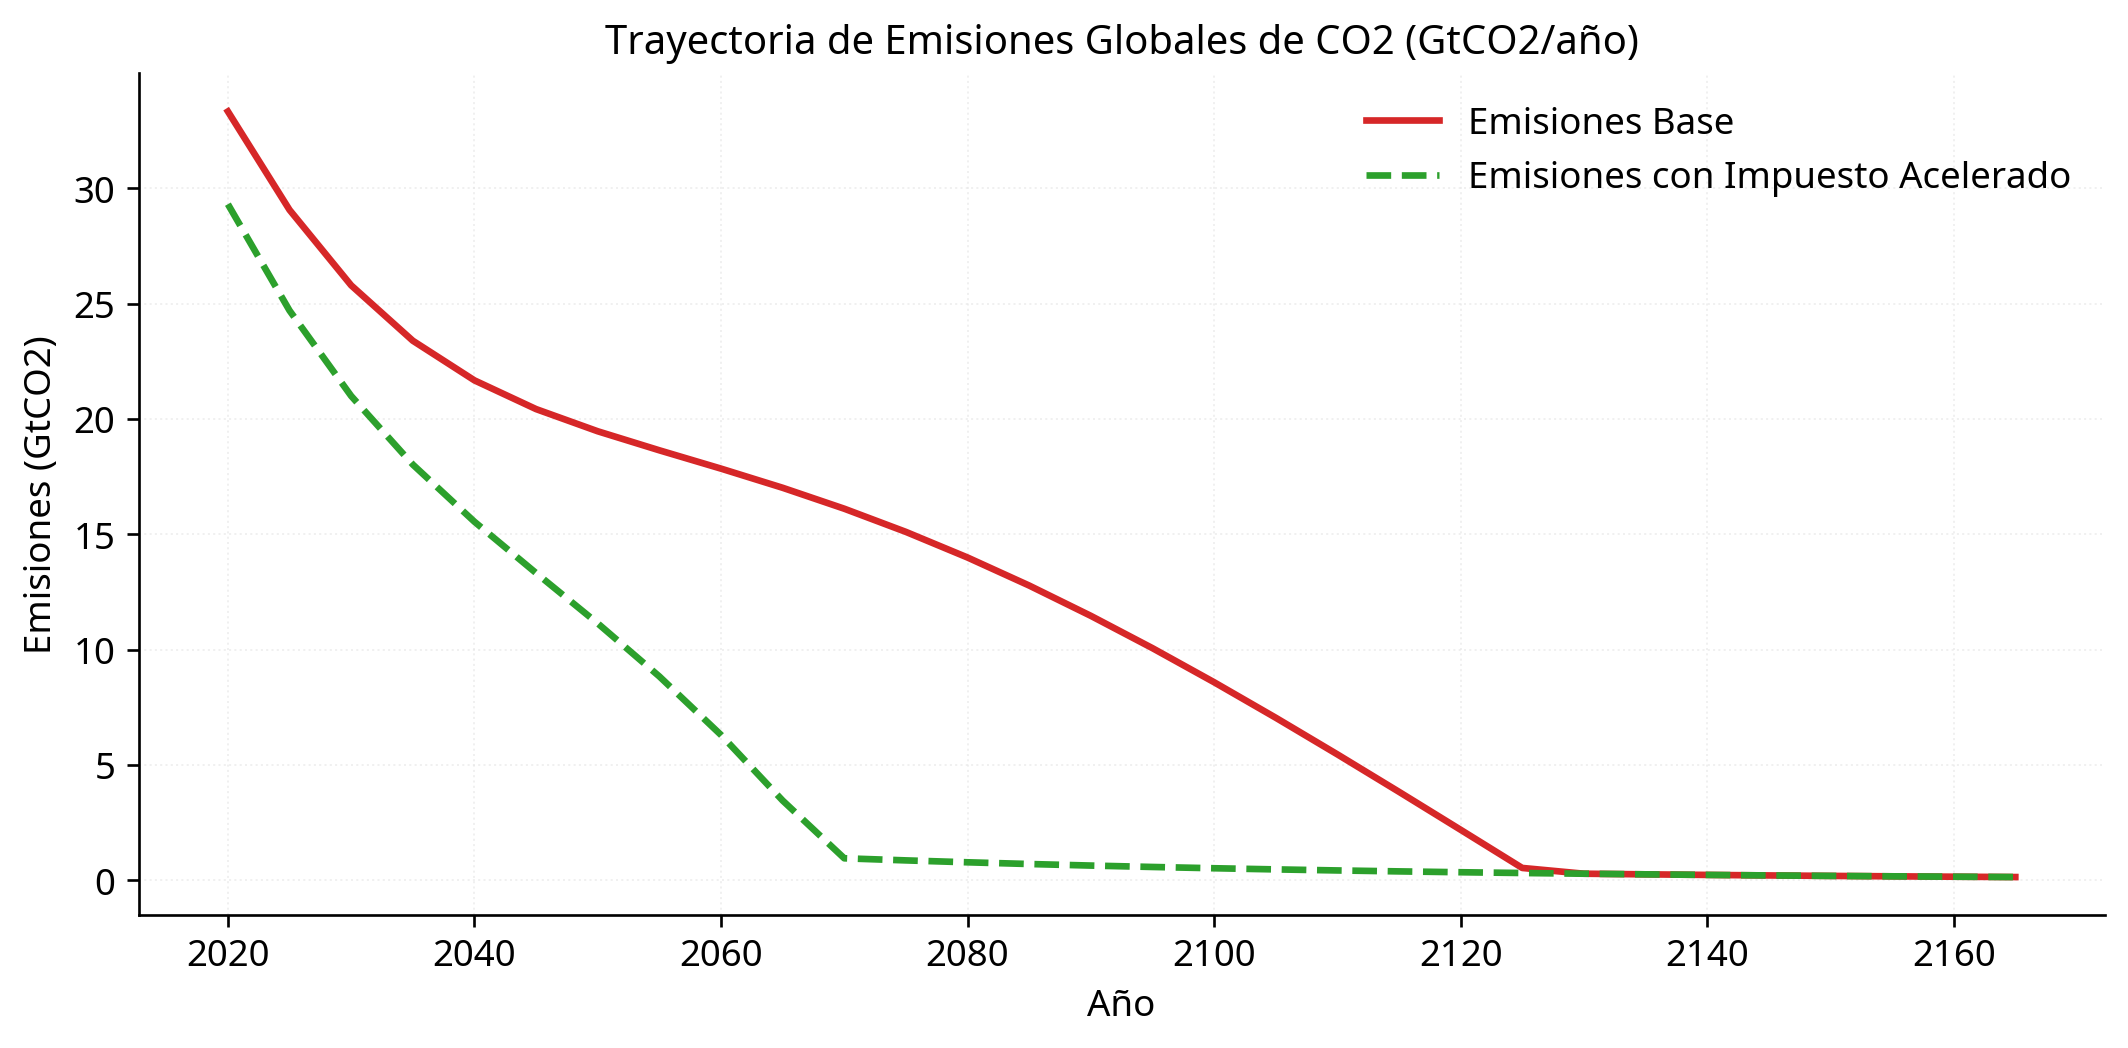

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(res_base.trajectories.index, res_base.trajectories["emissions"], color="#d62728", lw=2, label="Emisiones Base")
ax.plot(res_policy.trajectories.index, res_policy.trajectories["emissions"], color="#2ca02c", lw=2, linestyle="--", label="Emisiones con Impuesto Acelerado")
ax.set_title("Trayectoria de Emisiones Globales de CO2 (GtCO2/año)", fontsize=12, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Emisiones (GtCO2)")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Daños Macroeconómicos (% del Producto Mundial Bruto)

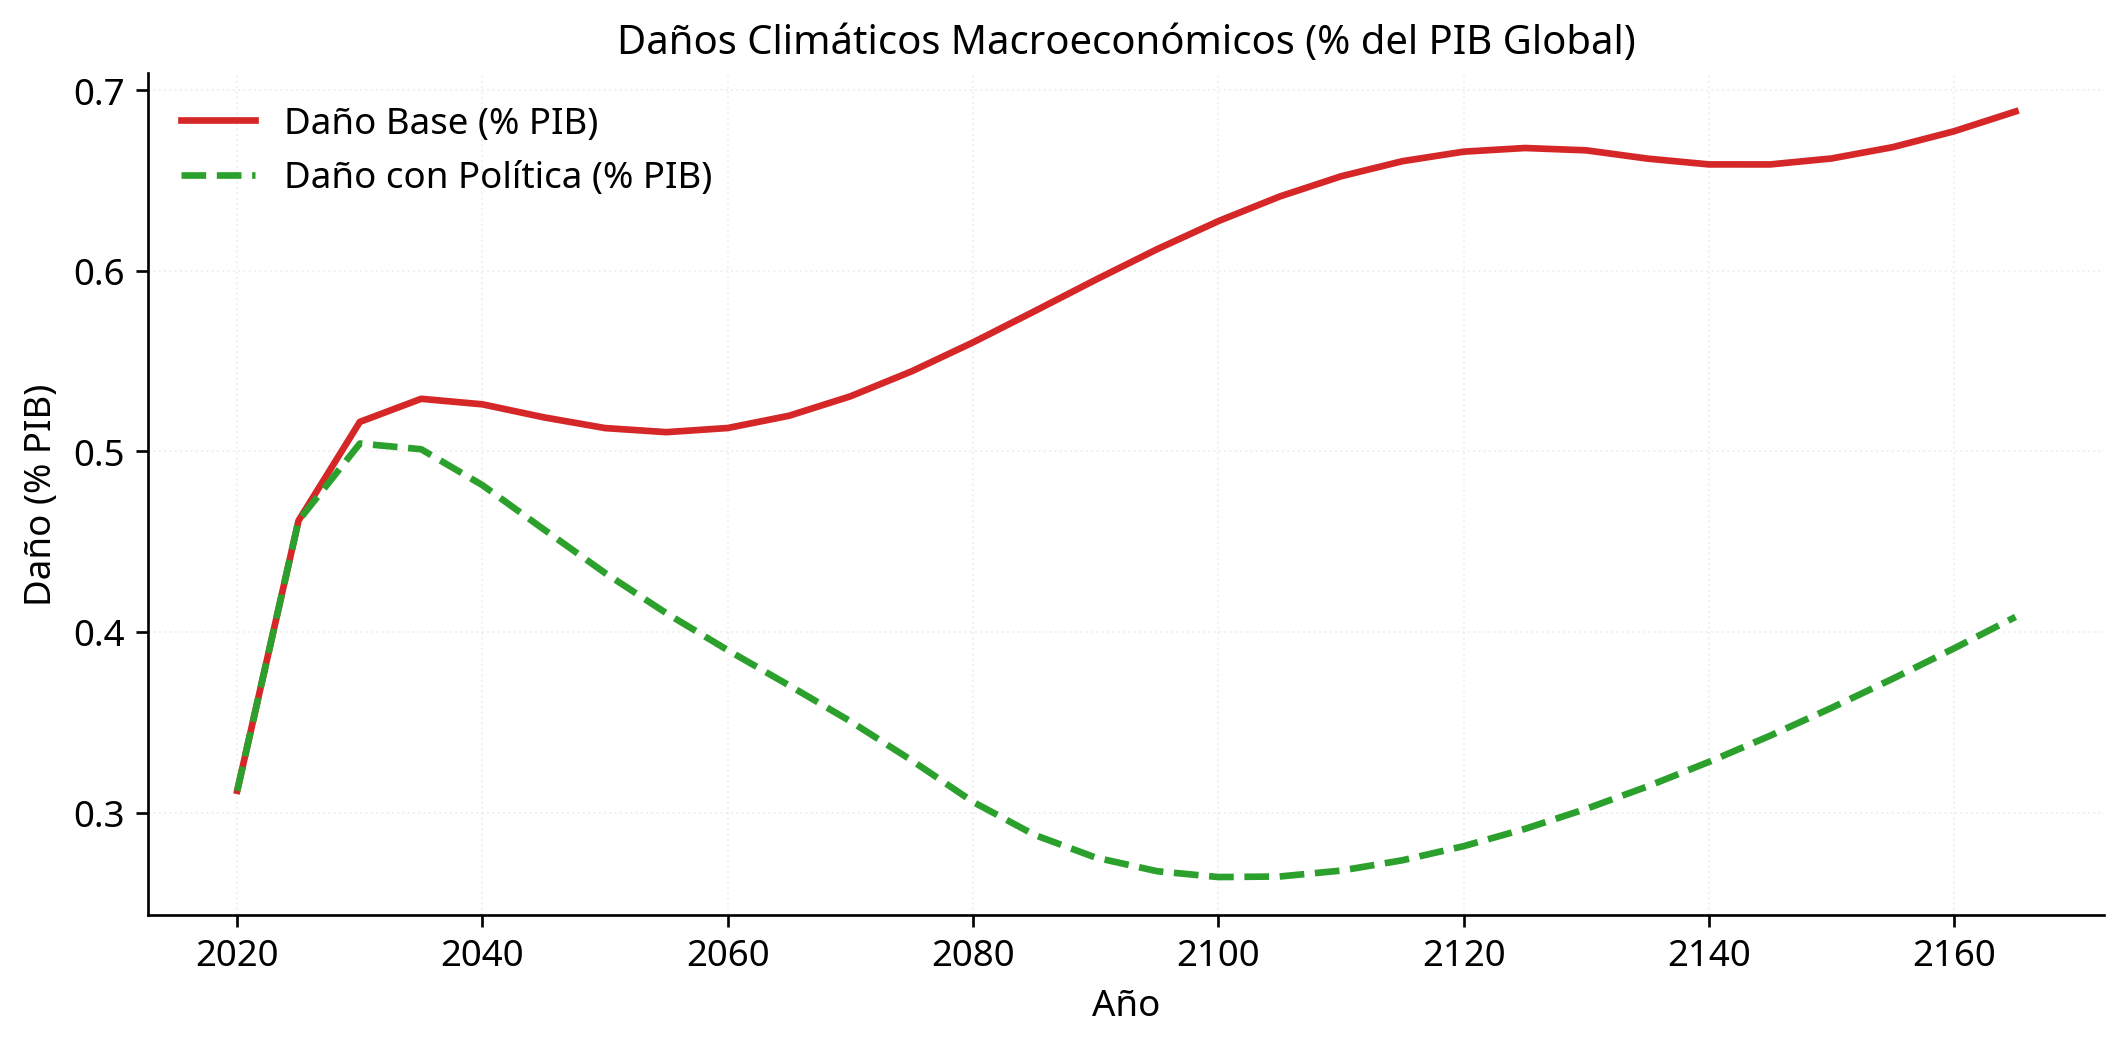

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(res_base.trajectories.index, res_base.trajectories["damage_fraction"] * 100, color="#d62728", lw=2, label="Daño Base (% PIB)")
ax.plot(res_policy.trajectories.index, res_policy.trajectories["damage_fraction"] * 100, color="#2ca02c", lw=2, linestyle="--", label="Daño con Política (% PIB)")
ax.set_title("Daños Climáticos Macroeconómicos (% del PIB Global)", fontsize=12, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Daño (% PIB)")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()